# 03 — Satellite View Segmentation

`POST /v1/satellite` classifies land cover (buildings, vegetation, pavement, etc.) at a tile centred on a point.

**Plan:** Premium only.

### Reference: filter types

The `date_time` payload follows the same shape as the heatmap endpoint:

| `filter_type` | Meaning | Required keyword args |
|---|---|---|
| `1` | Single hour | `start_date`, `start_time` |
| `2` | Range of hours (same day) | `start_date`, `start_time`, `end_time` |
| `3` | Single day (full 24 h; `start_time` ignored) | `start_date` |
| `4` | Range of days (window ≤ ~31 days) | `start_date`, `end_date` |

For satellite segmentation the per-tile composition is the same regardless of filter (surface composition doesn't change hour-to-hour), so the use-case notebooks use `filter_type=3` for consistency with the heatmap call.

### Reference: `granularity`

Same value space as the heatmap (`60`, `80`, `100` meters). For satellite this controls the *footprint* of the tile centered on the requested point — higher granularity = larger ground area sampled around the point. The client defaults to `100`; the use-case notebooks pass `80` explicitly for a good detail/speed balance.

### Reference: response schema

`client.satellite_segmentation(...)` returns `{"activity_id": str, "result": dict}`. The `result` carries:

- **`coordinates`** — `{latitude, longitude}` echoed back.
- **`image_year`** — vintage of the satellite imagery (e.g. `"2023"`).
- **`orignal_image`** — **list** of base64-encoded original tile(s) (note: the API spelling preserves the typo `orignal`; `original_image` may also be present).
- **`segmentation`**
  - `mode` — segmentation model identifier.
  - `image_content` — base64 of the segmented overlay.
  - `image_dimensions` — pixel dimensions.
  - `image_legend` — `{class_name: hex_color}` mapping for rendering the legend.
  - `segments` — `{class_name: percent_coverage}` per class.
  - `request_id`, `processing_time_seconds`.

### Reference: land-cover class vocabulary

The classes returned by the satellite model (illustrative — classes vary by location; this notebook queries Chicago):

| Class | Bucket the use-case notebooks group it into |
|---|---|
| `building` | impervious |
| `road, route` | impervious |
| `sidewalk, pavement` | impervious |
| `earth, ground` | impervious / bare |
| `tree` | canopy / vegetation |
| `plant` | vegetation |
| `grass` | vegetation |
| `others` | uncategorized |

> **Note on labels.** Composite classes use a `", "` separator inside the key (e.g. `"road, route"`). The use-case notebooks bucket by keyword match (`'road' in cls.lower()`), which absorbs label variations without needing an exact match.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dotenv import load_dotenv; load_dotenv(pathlib.Path.cwd().parent / '.env')

from fortyguard import FortyGuardClient
from fortyguard.samples import CHICAGO_POINT
client = FortyGuardClient()

In [2]:
response = client.satellite_segmentation(
    latitude=CHICAGO_POINT['latitude'],
    longitude=CHICAGO_POINT['longitude'],
    start_date='2024-07-15',
    start_time='14:00',
    filter_type=1,
    granularity=80,
)
result = response['result']
print('Image year:', result.get('image_year'))
print('Segmentation keys:', list(result.get('segmentation', {}).keys()))

Submitted -> activity_id=7ff770fe-b276-49bb-98c8-d3f9600ab11a
  status: processing
  status: completed
Done.
Image year: 2026
Segmentation keys: ['request_id', 'processing_time_seconds', 'image_dimensions', 'mode', 'segments', 'image_legend', 'image_content']


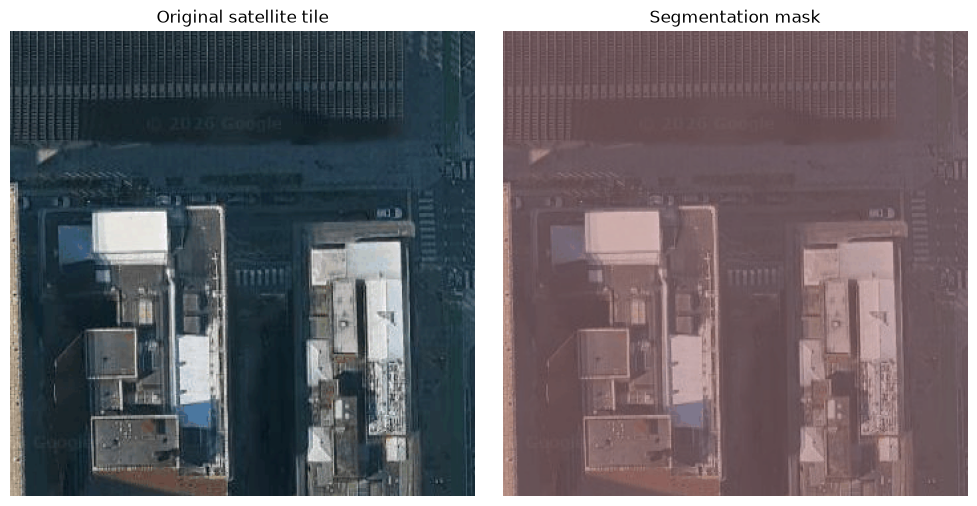

In [3]:
import base64, io
from PIL import Image
import matplotlib.pyplot as plt

def _decode(b64):
    if not b64: return None
    if b64.startswith('data:'):
        b64 = b64.split(',', 1)[1]
    return Image.open(io.BytesIO(base64.b64decode(b64)))

originals = result.get('orignal_image') or result.get('original_image') or []
if isinstance(originals, str):  # some responses return a single base64 string, not a list
    originals = [originals]
seg_b64 = result.get('segmentation', {}).get('image_content')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
orig = _decode(originals[0]) if originals else None
mask = _decode(seg_b64)
for ax, img, title in zip(axes, [orig, mask], ['Original satellite tile', 'Segmentation mask']):
    if img is not None:
        ax.imshow(img)
    ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()

In [4]:
# Coverage percentages per class.
segments = result.get('segmentation', {}).get('segments', {})
for cls, pct in sorted(segments.items(), key=lambda kv: kv[1], reverse=True):
    print(f'  {cls:>30}: {pct}')

                        building: 100.0
